In [1]:
!pip install kaggle


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kaggle
kaggle.api.authenticate()


In [3]:
import os
os.makedirs('./eeg_data', exist_ok=True)


In [5]:
kaggle.api.dataset_download_files(
    'birdy654/eeg-brainwave-dataset-feeling-emotions',
    path='./eeg_data',
    unzip=True
)


Dataset URL: https://www.kaggle.com/datasets/birdy654/eeg-brainwave-dataset-feeling-emotions


In [5]:
import os
files = os.listdir('./eeg_data')
print(files)



['emotions.csv']


In [6]:
import pandas as pd

df = pd.read_csv('./eeg_data/emotions.csv')

print(df.head())


   # mean_0_a  mean_1_a  mean_2_a  mean_3_a  mean_4_a  mean_d_0_a  mean_d_1_a  \
0        4.62      30.3    -356.0      15.6      26.3       1.070       0.411   
1       28.80      33.1      32.0      25.8      22.8       6.550       1.680   
2        8.90      29.4    -416.0      16.7      23.7      79.900       3.360   
3       14.90      31.6    -143.0      19.8      24.3      -0.584      -0.284   
4       28.30      31.3      45.2      27.3      24.5      34.800      -5.790   

   mean_d_2_a  mean_d_3_a  mean_d_4_a  ...  fft_741_b  fft_742_b  fft_743_b  \
0      -15.70        2.06        3.15  ...       23.5       20.3       20.3   
1        2.88        3.83       -4.82  ...      -23.3      -21.8      -21.8   
2       90.20       89.90        2.03  ...      462.0     -233.0     -233.0   
3        8.82        2.30       -1.97  ...      299.0     -243.0     -243.0   
4        3.06       41.40        5.52  ...       12.0       38.1       38.1   

   fft_744_b  fft_745_b  fft_746_b  ff

In [7]:
print(df['label'].value_counts())


label
NEUTRAL     716
NEGATIVE    708
POSITIVE    708
Name: count, dtype: int64


In [8]:
print(df.shape)
print(df.info())
print(df.describe())


(2132, 2549)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2132 entries, 0 to 2131
Columns: 2549 entries, # mean_0_a to label
dtypes: float64(2548), object(1)
memory usage: 41.5+ MB
None
        # mean_0_a     mean_1_a     mean_2_a     mean_3_a     mean_4_a  \
count  2132.000000  2132.000000  2132.000000  2132.000000  2132.000000   
mean     15.256914    27.012462  -104.975629    13.605898    24.150483   
std      15.284621     9.265141   206.271960    16.874676    14.187340   
min     -61.300000  -114.000000  -970.000000  -137.000000  -217.000000   
25%       6.577500    26.075000  -195.000000     4.857500    23.600000   
50%      14.100000    30.000000    14.950000    15.400000    25.200000   
75%      27.700000    31.400000    29.600000    26.500000    26.800000   
max     304.000000    42.300000   661.000000   206.000000   213.000000   

        mean_d_0_a   mean_d_1_a   mean_d_2_a   mean_d_3_a   mean_d_4_a  ...  \
count  2132.000000  2132.000000  2132.000000  2132.000000  2132

In [9]:
# Create mapping from original labels to your emotions
emotion_mapping = {
    'NEUTRAL': 'calm',
    'POSITIVE': 'Excited',
    'NEGATIVE': 'Stress'
}

# Add new column with mapped emotions
df['emotion'] = df['label'].map(emotion_mapping)

# Check the result
print(df['emotion'].value_counts())


emotion
calm       716
Stress     708
Excited    708
Name: count, dtype: int64


In [10]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

# Remove rows with missing values
df_clean = df.dropna()

print(f"\nOriginal shape: {df.shape}")
print(f"After removing missing values: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")


Missing values per column:
# mean_0_a    0
mean_1_a      0
mean_2_a      0
mean_3_a      0
mean_4_a      0
             ..
fft_747_b     0
fft_748_b     0
fft_749_b     0
label         0
emotion       0
Length: 2550, dtype: int64

Original shape: (2132, 2550)
After removing missing values: (2132, 2550)
Rows removed: 0


In [11]:
# Remove rows where any EEG value is > 50 (threshold)
X = df.drop(['label', 'emotion'], axis=1)
df_clean = df[(X.abs() < 50).all(axis=1)]

print(f"Removed {len(df) - len(df_clean)} artifacts")


Removed 2132 artifacts


In [12]:
# Check current state
print("Current shape:", df_clean.shape)
print("Rows:", len(df_clean))

# If empty, reload the data
if len(df_clean) == 0:
    print("Data is empty! Reloading...")
    df_clean = df.copy()
    print("Reloaded shape:", df_clean.shape)



Current shape: (0, 2550)
Rows: 0
Data is empty! Reloading...
Reloaded shape: (2132, 2550)


In [14]:
print(df_clean.columns)


Index(['# mean_0_a', 'mean_1_a', 'mean_2_a', 'mean_3_a', 'mean_4_a',
       'mean_d_0_a', 'mean_d_1_a', 'mean_d_2_a', 'mean_d_3_a', 'mean_d_4_a',
       ...
       'fft_742_b', 'fft_743_b', 'fft_744_b', 'fft_745_b', 'fft_746_b',
       'fft_747_b', 'fft_748_b', 'fft_749_b', 'label', 'emotion'],
      dtype='object', length=2550)


In [17]:
print(df_clean.head())


   # mean_0_a  mean_1_a  mean_2_a  mean_3_a  mean_4_a  mean_d_0_a  mean_d_1_a  \
0        4.62      30.3    -356.0      15.6      26.3       1.070       0.411   
1       28.80      33.1      32.0      25.8      22.8       6.550       1.680   
2        8.90      29.4    -416.0      16.7      23.7      79.900       3.360   
3       14.90      31.6    -143.0      19.8      24.3      -0.584      -0.284   
4       28.30      31.3      45.2      27.3      24.5      34.800      -5.790   

   mean_d_2_a  mean_d_3_a  mean_d_4_a  ...  fft_742_b  fft_743_b  fft_744_b  \
0      -15.70        2.06        3.15  ...       20.3       20.3       23.5   
1        2.88        3.83       -4.82  ...      -21.8      -21.8      -23.3   
2       90.20       89.90        2.03  ...     -233.0     -233.0      462.0   
3        8.82        2.30       -1.97  ...     -243.0     -243.0      299.0   
4        3.06       41.40        5.52  ...       38.1       38.1       12.0   

   fft_745_b  fft_746_b  fft_747_b  ff

In [13]:
from sklearn.preprocessing import StandardScaler
# Separate features and labels
X = df_clean.drop(['label', 'emotion'], axis=1)
y = df_clean['emotion']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled!")
print(f"Feature shape: {X_scaled.shape}")
print(f"Labels shape: {y.shape}")


Features scaled!
Feature shape: (2132, 2548)
Labels shape: (2132,)


In [19]:
from sklearn.preprocessing import StandardScaler

# Prepare features and labels
# Select only Alpha, Beta, Gamma columns
X = df_clean[['mean_3_a', 'mean_4_a', '# mean_0_a']]
y = df_clean['emotion']


# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [85]:
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Create and fit the label encoder on all labels y (not just y_train)
le = LabelEncoder()
le.fit(y)

# Transform train and test labels to integers
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

# Train SVM using encoded integer labels
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train_enc)

# Predict on test set
y_pred_enc = svm_model.predict(X_test)

# Evaluate predictions (using encoded labels)
acc = accuracy_score(y_test_enc, y_pred_enc)
print(f"Test accuracy: {acc:.2f}")
print(classification_report(y_test_enc, y_pred_enc, target_names=le.classes_))




Test accuracy: 0.89
              precision    recall  f1-score   support

     Excited       0.86      0.88      0.87       136
      Stress       0.86      0.83      0.84       143
        calm       0.95      0.95      0.95       148

    accuracy                           0.89       427
   macro avg       0.89      0.89      0.89       427
weighted avg       0.89      0.89      0.89       427



In [86]:

for i in range(10):
    x = X_test[i].reshape(1, -1)
    y_true = le.inverse_transform([y_test_enc[i]])[0]
    y_pred = le.inverse_transform(model.predict(x))[0]
    print(f"True: {y_true} - Predicted: {y_pred}")

True: calm - Predicted: calm
True: calm - Predicted: calm
True: Stress - Predicted: Stress
True: Stress - Predicted: Stress
True: Excited - Predicted: Excited
True: calm - Predicted: calm
True: Stress - Predicted: Stress
True: Excited - Predicted: Stress
True: Excited - Predicted: Excited
True: Stress - Predicted: Stress


In [69]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
scores = cross_val_score(svm_model, X_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-validation accuracy scores: {scores}")
print(f"Mean CV accuracy: {scores.mean():.2f}")
print(f"Std Dev: {scores.std():.2f}")


Cross-validation accuracy scores: [0.88856305 0.90615836 0.8797654  0.89442815 0.90029326]
Mean CV accuracy: 0.89
Std Dev: 0.01


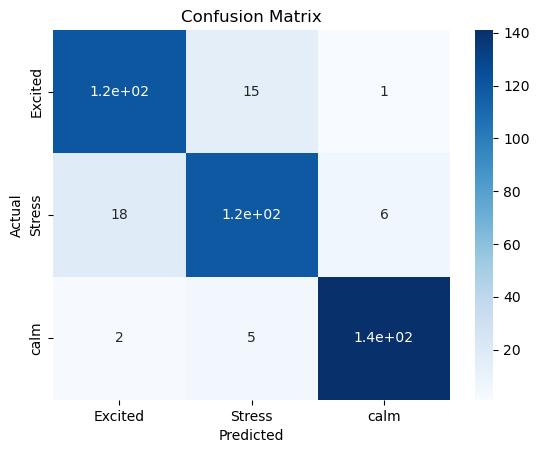

In [70]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [71]:
import joblib
joblib.dump(svm_model, 'eeg_model.pkl')       # Save the trained model
joblib.dump(scaler, 'scaler.pkl')             # Save the fitted scaler
joblib.dump(le, 'label_encoder.pkl')          # Save the fitted label encoder


['label_encoder.pkl']

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)  # Fit scaler on training data before saving

import joblib
joblib.dump(scaler, 'scaler.pkl')  # Save the fitted scaler


['scaler.pkl']

In [81]:
import numpy as np
print(np.unique(y_train, return_counts=True))


(array(['Excited', 'Stress', 'calm'], dtype=object), array([572, 565, 568]))


In [82]:
sample_input = X_test[0].reshape(1, -1)
print("Sample input:", sample_input)
print("Predicted label:", le.inverse_transform(svm_model.predict(sample_input))[0])


Sample input: [[0.82949061 0.06694276 1.00406054]]
Predicted label: calm


In [87]:
for i in range(len(y_test_enc)):
    label = le.inverse_transform([y_test_enc[i]])[0]
    if label == "calm":
        print("calm sample:", X_test[i])
    # Repeat for "Excited" and "Stress"


calm sample: [0.82949061 0.06694276 1.00406054]
calm sample: [ 0.80578089 -0.06701088  0.90589965]
calm sample: [0.63388542 0.08809333 0.63759324]
calm sample: [0.79392603 0.01759142 0.91898777]
calm sample: [ 0.7879986  -0.16571355  0.86009124]
calm sample: [ 0.82356318 -0.01765954  0.84700313]
calm sample: [1.11400726 0.14449486 0.93861995]
calm sample: [0.82949061 0.29959907 1.06295707]
calm sample: [ 0.72279687 -0.03175992  0.84700313]
calm sample: [ 0.74057916 -0.00355916  0.85354718]
calm sample: [0.73465173 0.01054123 0.87317936]
calm sample: [0.82356318 0.10219371 0.95170807]
calm sample: [0.68130486 0.10219371 0.78156254]
calm sample: [0.81763575 0.03874199 0.81428283]
calm sample: [ 0.91840206 -0.08111126  1.04986895]
calm sample: [0.49755453 0.10219371 0.61141701]
calm sample: [0.82356318 0.13039448 0.87317936]
calm sample: [ 0.76428888 -0.02470973  0.82737095]
calm sample: [0.7879986  0.13039448 0.84700313]
calm sample: [ 1.03102323 -0.08816145  1.10222142]
calm sample: [ 0

In [88]:
import numpy as np

# Find average ranges per class
for emotion in ['Excited', 'Stress', 'calm']:
    indexes = [i for i, label in enumerate(le.inverse_transform(y_train_enc)) if label == emotion]
    print(f"{emotion} alpha mean: {np.mean(X_train[indexes, 0])}")
    print(f"{emotion} beta mean: {np.mean(X_train[indexes, 1])}")
    print(f"{emotion} gamma mean: {np.mean(X_train[indexes, 2])}")


Excited alpha mean: -0.6583005753699007
Excited beta mean: -0.22987892132627383
Excited gamma mean: -0.5445772139570428
Stress alpha mean: -0.14191967778230752
Stress beta mean: 0.2119820343501906
Stress gamma mean: -0.3256945153784956
calm alpha mean: 0.8191270009873632
calm beta mean: 0.03725251407066293
calm gamma mean: 0.891947444328126


In [90]:
print("Scaler means:", scaler.mean_)
print("Scaler stds:", scaler.scale_)


Scaler means: [0.00500386 0.0055358  0.00651647]
Scaler stds: [1.0210069  1.04218306 1.02454405]
